# FinPersona Bangladesh — Who Is Left Out, and Which Lenders Are at Risk

**A data-science study of Bangladesh's financial system: the people it reaches, the people it misses, and the banks and NBFIs that serve them.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USERNAME/finpersona-bangladesh/blob/main/FinPersona_Bangladesh.ipynb)

---

## Why this project

Bangladesh has 120+ million adults, one of the world's best-known mobile-money markets, 36 listed banks and 23 listed NBFIs
(non-bank financial institutions — leasing and finance companies such as IDLC and IPDC). Yet:

* fewer than half of Bangladeshi adults have an account — and the share **fell** between 2021 and 2024;
* seven in ten adults borrowed money in the past year, mostly **outside** the formal system;
* in late 2025 the central bank merged five failing Islamic banks into one new bank and wrote their shares down to zero.

This notebook turns two free, official public datasets into answers that a bank, NBFI or mobile-financial-services (MFS) company can act on.

| Part | Question | Data | Machine learning |
|---|---|---|---|
| **A. People** | Who is excluded, how many of them, and how far behind is Bangladesh compared with countries like it? | World Bank **Global Findex 2025** — Bangladesh 2011–2024 by 12 population groups, plus 140+ countries | Country segmentation (K-Means), **Inclusion-Gap model** (gradient boosting, leave-country-out validation) |
| **B. Institutions** | Which listed banks and NBFIs are healthy, which are in danger, and could the danger have been seen early? | **Dhaka Stock Exchange** daily prices and company data for every listed company, Sep 2024 → Oct 2026 | Lender personas (K-Means), **Early-Warning model**, real-world test against the 2025 bank merger |
| **C. Dashboard** | What should a CEO take away? | — | — |

### About the data — read this first
Bangladeshi banks do not publish customer-level records (that would break customer privacy), so **no real, individual-level Bangladeshi
bank-customer dataset is freely available anywhere**. Anyone who claims otherwise is using synthetic data. This project uses the two best
*real* public sources instead:

1. **Global Findex 2025** (World Bank): a nationally representative survey of adults in every country, published as percentages for the whole
   population and for 12 groups (women, men, poorer, richer, young, older, rural, urban, by education, by employment). Downloaded from the World Bank's official site.
2. **Dhaka Stock Exchange market data**: daily prices of every listed company, collected automatically from the DSE website every trading day, plus each company's
   category (A / B / Z), shareholding, reserves and dividend record.

Every number is checked against published values before analysis. **No API keys, no logins, no Kaggle.** `Runtime → Run all` in Colab (about 3–5 minutes).

---
# 0. Setup

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "openpyxl"], check=False)

In [2]:
import io, re, urllib.request, warnings
from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import lightgbm as lgb

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, silhouette_score
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
SEED = 42
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

# ---------- One consistent, colour-blind-checked visual style ----------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = PALETTE
INK, INK2, MUTED, GRID, BASELINE, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
LIGHTBLUE, PALEGRAY = "#86b6ef", "#d5d3cc"
BLUES = LinearSegmentedColormap.from_list("blues", ["#f4f8fe", "#86b6ef", "#2a78d6", "#104281"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.fontsize": 9.5, "lines.linewidth": 2, "figure.dpi": 110,
})
PCT = mtick.PercentFormatter(1, decimals=0)

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight"); plt.show()

def pct(x, d=0):
    return f"{100*x:.{d}f}%"

def mn(x):
    return f"{x/1e6:,.1f} million"

def bar_labels(ax, fmt="{:.0%}", horizontal=False, pad=3, size=9):
    for p in ax.patches:
        v = p.get_width() if horizontal else p.get_height()
        if np.isnan(v):
            continue
        if horizontal:
            ax.annotate(fmt.format(v), (v, p.get_y() + p.get_height() / 2), xytext=(pad if v >= 0 else -pad, 0), textcoords="offset points",
                        va="center", ha="left" if v >= 0 else "right", fontsize=size, color=INK2)
        else:
            ax.annotate(fmt.format(v), (p.get_x() + p.get_width() / 2, v), xytext=(0, pad), textcoords="offset points",
                        va="bottom", ha="center", fontsize=size, color=INK2)

def hbar_style(ax):
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)

---
# 1. Data — official sources, verified

Each loader looks for a local copy first (if you cloned the repository), then the **official source**, then a public mirror of the same file.
The DSE files are pinned to a fixed date so your results match this report exactly; set `DSE_LIVE = True` to pull the very latest trading day instead.

In [3]:
DSE_LIVE = False
DSE_PIN = "1c6566db3eab6b7f494bf10b3356f700b6fbfbdf"        # snapshot of 5 Oct 2026
DSE_REF = "main" if DSE_LIVE else DSE_PIN

SOURCES = {
    "findex": ["https://thedocs.worldbank.org/en/doc/be6615202d1f08a25855c8ac2d615122-0050012025/related/GlobalFindexDatabase2025.xlsx",
               "https://raw.githubusercontent.com/ReinaVisiy/findex-gap-analysis/955db575d796e9cd43a21096eaabb9a0445c006e/data/raw/GlobalFindexDatabase2025.xlsx"],
    "dse_prices": [f"https://raw.githubusercontent.com/nifty1303/dse-data/{DSE_REF}/data/prices.csv"],
    "dse_fundamentals": [f"https://raw.githubusercontent.com/nifty1303/dse-data/{DSE_REF}/data/fundamentals.csv"],
}
LOCAL = {"findex": DATA_DIR / "GlobalFindexDatabase2025.xlsx", "dse_prices": DATA_DIR / "dse_prices.csv",
         "dse_fundamentals": DATA_DIR / "dse_fundamentals.csv"}

def get(name):
    if LOCAL[name].exists() and not (DSE_LIVE and name.startswith("dse")):
        return LOCAL[name].read_bytes(), f"local copy ({LOCAL[name]})"
    for url in SOURCES[name]:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (FinPersona research notebook)"})
            with urllib.request.urlopen(req, timeout=90) as r:
                blob = r.read()
            LOCAL[name].write_bytes(blob)
            return blob, url.split("/")[2]
        except Exception as e:
            print(f"  {name}: {url.split('/')[2]} unavailable ({type(e).__name__}), trying next source…")
    raise RuntimeError(f"Could not download {name}")

blob, src_fx = get("findex")
findex = pd.read_excel(io.BytesIO(blob), sheet_name="Data", skiprows=[1])          # row 2 holds long labels
series = pd.read_excel(io.BytesIO(blob), sheet_name="Series Table")
LABEL = dict(zip(series["Series"], series["Indicator name"]))
blob, src_px = get("dse_prices");       prices = pd.read_csv(io.BytesIO(blob), parse_dates=["date"])
blob, src_fu = get("dse_fundamentals"); fund = pd.read_csv(io.BytesIO(blob))

# ---- Integrity checks against values published by the World Bank ----
bgd_all = findex[(findex.codewb == "BGD") & (findex.group == "all")].set_index("year")
assert abs(bgd_all.loc[2024, "account.t.d"] - 0.4328) < 0.005, "Bangladesh 2024 account ownership should be 43.3% (World Bank WDI FX.OWN.TOTL.ZS)"
assert abs(bgd_all.loc[2021, "account.t.d"] - 0.5281) < 0.005, "Bangladesh 2021 account ownership should be 52.8%"
assert findex.codewb.nunique() > 140
# ---- DSE sanity checks ----
assert {"IDLC", "IPDC", "BRACBANK", "CITYBANK"} <= set(prices.symbol)
assert prices.date.max() - prices.date.min() > pd.Timedelta(days=360)

print(f"Findex 2025      : {findex.shape[0]:,} rows · {findex.codewb.nunique()} economies · years {sorted(findex.year.unique())} · source: {src_fx}")
print(f"DSE prices       : {len(prices):,} rows · {prices.symbol.nunique()} instruments · {prices.date.min():%d %b %Y} → {prices.date.max():%d %b %Y} · source: {src_px}")
print(f"DSE company data : {fund.symbol.nunique()} companies · snapshot {fund.snapshot_date.max()} · source: {src_fu}")
print("\n✔ Bangladesh account ownership matches the World Bank's published figures (52.8% in 2021, 43.3% in 2024).")

Findex 2025      : 8,577 rows · 174 economies · years [np.int64(2011), np.int64(2014), np.int64(2017), np.int64(2021), np.int64(2022), np.int64(2024)] · source: local copy (data/GlobalFindexDatabase2025.xlsx)
DSE prices       : 203,172 rows · 426 instruments · 30 Sep 2024 → 05 Oct 2026 · source: local copy (data/dse_prices.csv)
DSE company data : 419 companies · snapshot 2026-10-03 · source: local copy (data/dse_fundamentals.csv)

✔ Bangladesh account ownership matches the World Bank's published figures (52.8% in 2021, 43.3% in 2024).


---
# PART A — People: the financial lives of Bangladeshi adults

Findex reports each indicator as a **share of adults (age 15+)**, for everyone and for 12 groups. The file also contains Bangladesh's adult
population, so every percentage can be turned into **millions of people** — the number a business actually plans with.

In [4]:
BGD = findex[findex.codewb == "BGD"].copy()
POP = {int(y): float(v) for y, v in bgd_all["pop_adult"].items()}
b24 = BGD[BGD.year == 2024].set_index("group2")
print(f"Bangladesh adults (15+): {POP[2011]/1e6:.1f}M in 2011 → {POP[2024]/1e6:.1f}M in 2024")

def ind(code, year=2024, seg="all"):
    """One Findex value for Bangladesh."""
    row = BGD[(BGD.year == year) & (BGD.group2 == seg)]
    return float(row[code].iloc[0]) if len(row) and code in row else np.nan

Bangladesh adults (15+): 100.4M in 2011 → 122.8M in 2024


## A1. Thirteen years in one chart — progress, then a reversal

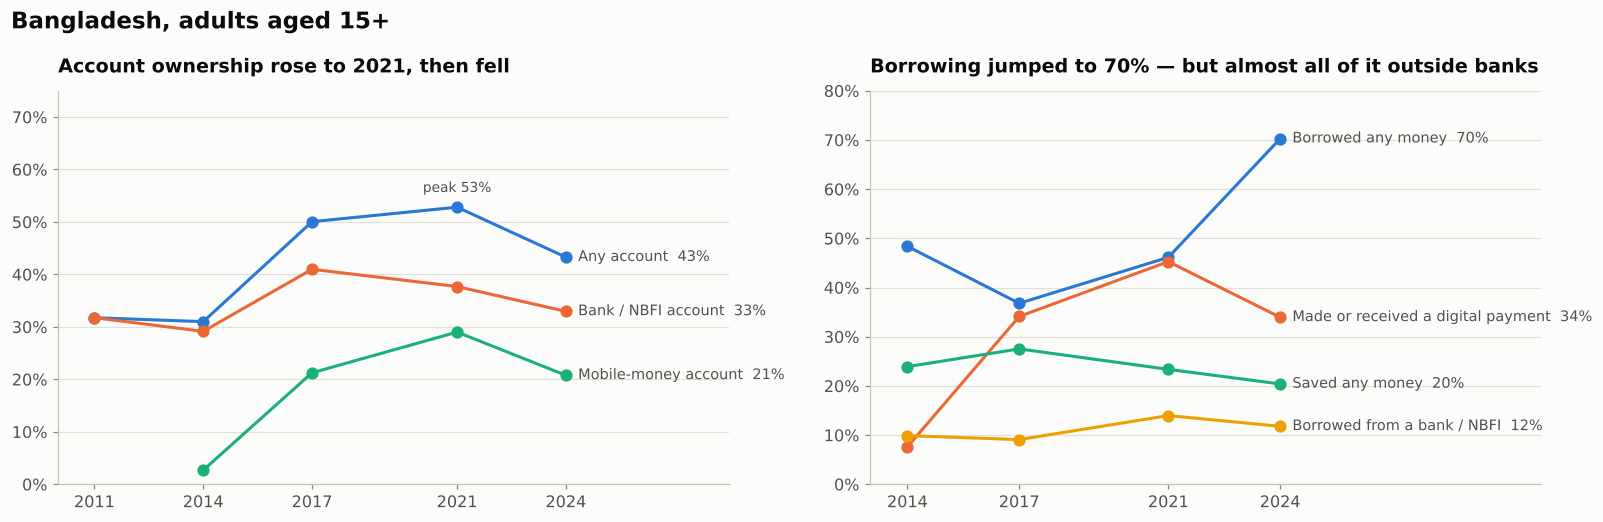

Account ownership fell 9.5 points between 2021 and 2024 — while the adult population grew by 5.2M.
Adults with an account: 62.1M (2021) → 53.2M (2024)


In [5]:
years = [2011, 2014, 2017, 2021, 2024]
T = bgd_all.loc[years]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
for code, name, c in [("account.t.d", "Any account", BLUE), ("fiaccount.t.d", "Bank / NBFI account", ORANGE), ("mobileaccount.t.d", "Mobile-money account", AQUA)]:
    s = T[code].dropna(); ax.plot(s.index, s.values, marker="o", ms=7, color=c)
    ax.annotate(f"{name}  {s.iloc[-1]:.0%}", (s.index[-1], s.iloc[-1]), xytext=(8, 0), textcoords="offset points", va="center", color=INK2, fontsize=9.5)
ax.annotate("peak 53%", (2021, T.loc[2021, "account.t.d"]), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9, color=INK2)
ax.set_title("Account ownership rose to 2021, then fell"); ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, 0.75)
ax.set_xticks(years); ax.set_xlim(2010, 2028.5)
ax = axes[1]
for code, name, c in [("borrow.any.t.d", "Borrowed any money", BLUE), ("g20.any", "Made or received a digital payment", ORANGE),
                      ("save.any.t.d", "Saved any money", AQUA), ("fin22a", "Borrowed from a bank / NBFI", YELLOW)]:
    s = T[code].dropna(); ax.plot(s.index, s.values, marker="o", ms=7, color=c)
    ax.annotate(f"{name}  {s.iloc[-1]:.0%}", (s.index[-1], s.iloc[-1]), xytext=(8, 0), textcoords="offset points", va="center", color=INK2, fontsize=9.5)
ax.set_title("Borrowing jumped to 70% — but almost all of it outside banks"); ax.yaxis.set_major_formatter(PCT); ax.set_ylim(0, 0.8)
ax.set_xticks(years[1:]); ax.set_xlim(2013, 2031)
fig.suptitle("Bangladesh, adults aged 15+", x=0.01, ha="left", fontsize=15, fontweight="bold", color=INK)
fig.tight_layout(); savefig(fig, "A1_bangladesh_trends")

drop = (T.loc[2021, "account.t.d"] - T.loc[2024, "account.t.d"])
print(f"Account ownership fell {drop*100:.1f} points between 2021 and 2024 — while the adult population grew by {(POP[2024]-POP[2021])/1e6:.1f}M.")
print(f"Adults with an account: {T.loc[2021,'account.t.d']*POP[2021]/1e6:.1f}M (2021) → {T.loc[2024,'account.t.d']*POP[2024]/1e6:.1f}M (2024)")

**What happened?** The fall is concentrated in **mobile-money accounts** (29% → 21%) and bank accounts (38% → 33%). Findex counts an account only if the person
used it in the past year, so the drop means millions of people **stopped using** their accounts, not that accounts were closed.
Saving also fell (23% → 20%) while borrowing jumped (46% → 70%): the 2022–24 period of high inflation pushed households from saving to borrowing.

## A2. Who is left out — the gaps inside Bangladesh

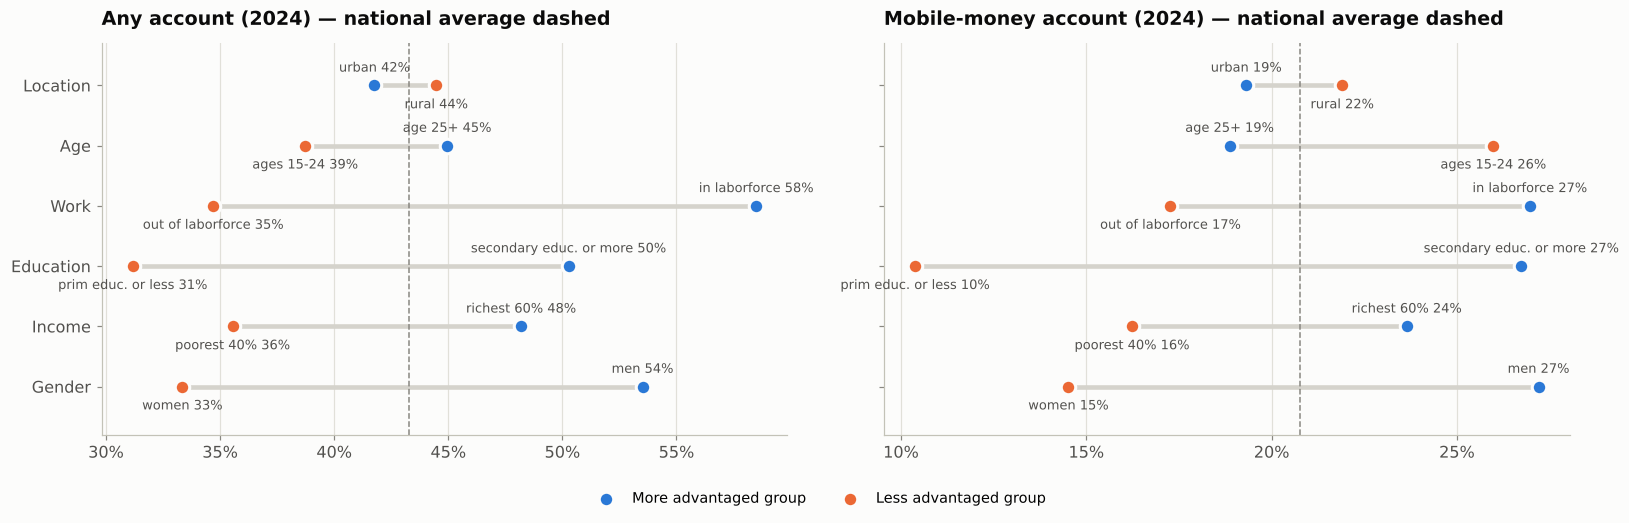

divide,advantaged,disadvantaged,account gap (pts),mobile-money gap (pts)
Work,in laborforce,out of laborforce,24,10
Gender,men,women,20,13
Education,secondary edu or more,prim edu or less,19,16
Income,richest 60%,poorest 40%,13,7
Age,age 25+,ages 15-24,6,-7
Location,urban,rural,-3,-3


In [6]:
PAIRS = [("men", "women", "Gender"), ("richest 60%", "poorest 40%", "Income"), ("secondary edu or more", "prim edu or less", "Education"),
         ("in laborforce", "out of laborforce", "Work"), ("age 25+", "ages 15-24", "Age"), ("urban", "rural", "Location")]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for ax, code, title in [(axes[0], "account.t.d", "Any account"), (axes[1], "mobileaccount.t.d", "Mobile-money account")]:
    for i, (a, b, lab) in enumerate(PAIRS):
        va, vb = b24.loc[a, code], b24.loc[b, code]
        ax.plot([va, vb], [i, i], color=PALEGRAY, lw=3, zorder=1)
        ax.scatter([va], [i], s=90, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=2, label="More advantaged group" if i == 0 else None)
        ax.scatter([vb], [i], s=90, color=ORANGE, zorder=3, edgecolor=SURFACE, linewidth=2, label="Less advantaged group" if i == 0 else None)
        ax.annotate(f"{a.replace('edu', 'educ.')} {va:.0%}", (va, i), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
        ax.annotate(f"{b.replace('edu', 'educ.')} {vb:.0%}", (vb, i), xytext=(0, -15), textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
    ax.axvline(b24.loc["all", code], color=MUTED, ls="--", lw=1)
    ax.set_yticks(range(len(PAIRS))); ax.set_yticklabels([p[2] for p in PAIRS]); ax.set_ylim(-0.8, len(PAIRS) - 0.3)
    ax.xaxis.set_major_locator(mtick.MultipleLocator(0.05)); ax.xaxis.set_major_formatter(PCT)
    ax.set_title(f"{title} (2024) — national average dashed"); hbar_style(ax)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.04, 1, 1)); savefig(fig, "A2_inclusion_gaps")

gap_tbl = pd.DataFrame([{"divide": lab, "advantaged": a, "disadvantaged": b,
                         "account gap (pts)": 100 * (b24.loc[a, "account.t.d"] - b24.loc[b, "account.t.d"]),
                         "mobile-money gap (pts)": 100 * (b24.loc[a, "mobileaccount.t.d"] - b24.loc[b, "mobileaccount.t.d"])} for a, b, lab in PAIRS])
gap_tbl.sort_values("account gap (pts)", ascending=False).style.format({"account gap (pts)": "{:.0f}", "mobile-money gap (pts)": "{:.0f}"}).hide(axis="index")

The biggest divide is **work** (24 points): adults outside the labour force are far less likely to have an account. **Gender** (20 points) and
**education** (19 points) follow. Two surprises: young adults are *more* likely than older ones to use mobile money, and rural adults are
*as* likely as urban ones to have an account — a sign of how far mobile money and agent banking have reached.

## A3. Sizing the market — turning percentages into people

Findex gives percentages for each group but not the size of each group. We recover the group sizes with simple algebra: for any indicator,
*national value = share × group A value + (1 − share) × group B value*, so **share = (national − B) / (A − B)**. Taking the median across
hundreds of indicators gives the estimate. Two built-in checks: the income split comes out at about 40/60, as defined, and the estimates from
different indicators agree to within a fraction of a percentage point — so these are effectively the survey's own population weights.

Estimated share of Bangladeshi adults in each group (2024):
{'men': '49%', 'women': '51%', 'richest 60%': '61%', 'poorest 40%': '39%', 'secondary edu or more': '63%', 'prim edu or less': '37%', 'in laborforce': '36%', 'out of laborforce': '64%', 'age 25+': '73%', 'ages 15-24': '27%', 'urban': '44%', 'rural': '56%'}


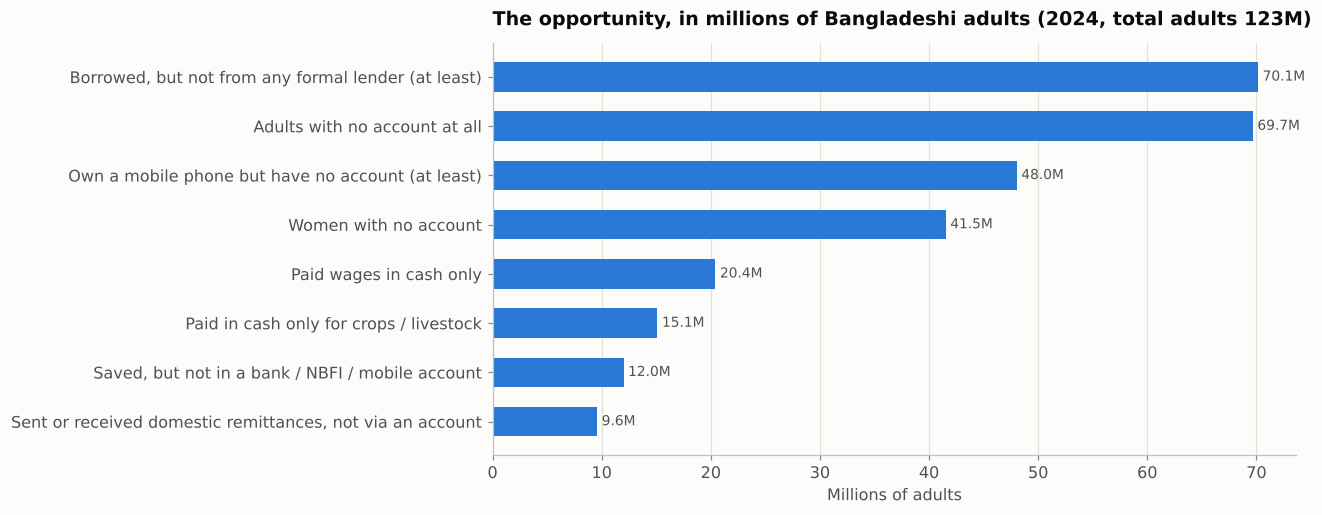

segment,adults (millions),product opportunity
"Borrowed, but not from any formal lender (at least)",70.1,"Nano-loans, NBFI microcredit"
Adults with no account at all,69.7,Core unbanked market
Own a mobile phone but have no account (at least),48.0,Digital onboarding — the phone is already in hand
Women with no account,41.5,Women-focused products
Paid wages in cash only,20.4,Payroll accounts
Paid in cash only for crops / livestock,15.1,"Agri-payments, supply-chain finance"
"Saved, but not in a bank / NBFI / mobile account",12.0,Deposit / DPS products
"Sent or received domestic remittances, not via an account",9.6,"Transfers, MFS"


In [7]:
def group_share(a, b, year=2024):
    """Estimated share of adults in group `a` (vs. `b`), from the national average identity."""
    rows = BGD[BGD.year == year].set_index("group2")
    num = [c for c in findex.columns[8:] if pd.api.types.is_numeric_dtype(findex[c])]
    allv, va, vb = rows.loc["all", num], rows.loc[a, num], rows.loc[b, num]
    ok = (va - vb).abs() > 0.05
    w = ((allv - vb) / (va - vb))[ok]
    w = w[(w > 0) & (w < 1)]
    assert w.quantile(0.75) - w.quantile(0.25) < 0.01, f"inconsistent group weights for {a}"
    return float(w.median())

SHARE = {}
for a, b, _ in PAIRS:
    SHARE[a] = group_share(a, b); SHARE[b] = 1 - SHARE[a]
assert abs(SHARE["poorest 40%"] - 0.40) < 0.02, "income split must come out at 40/60"
print("Estimated share of Bangladeshi adults in each group (2024):")
print({k: f"{v:.0%}" for k, v in SHARE.items()})

def people(code, seg="all", year=2024):
    return ind(code, year, seg) * POP[year] * (1 if seg == "all" else SHARE[seg])

N = POP[2024]
market = pd.DataFrame([
    ("Adults with no account at all", (1 - ind("account.t.d")) * N, "Core unbanked market"),
    ("Women with no account", (1 - ind("account.t.d", seg="women")) * N * SHARE["women"], "Women-focused products"),
    ("Own a mobile phone but have no account (at least)", max(ind("con1") - ind("account.t.d"), 0) * N, "Digital onboarding — the phone is already in hand"),
    ("Borrowed, but not from any formal lender (at least)", (ind("borrow.any.t.d") - ind("fin22a.22a1.22g.d")) * N, "Nano-loans, NBFI microcredit"),
    ("Paid wages in cash only", ind("fin34c") * N, "Payroll accounts"),
    ("Paid in cash only for crops / livestock", ind("fin43c") * N, "Agri-payments, supply-chain finance"),
    ("Sent or received domestic remittances, not via an account", (ind("fh1.fh2") - ind("fin28.29")) * N, "Transfers, MFS"),
    ("Saved, but not in a bank / NBFI / mobile account", (ind("save.any.t.d") - ind("fin17a.17a1.d")) * N, "Deposit / DPS products"),
], columns=["segment", "adults", "product opportunity"])
market["adults (millions)"] = market["adults"] / 1e6
market = market.sort_values("adults", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.barh(market["segment"], market["adults (millions)"], color=BLUE, height=0.6); ax.invert_yaxis()
bar_labels(ax, fmt="{:.1f}M", horizontal=True); hbar_style(ax)
ax.set_title(f"The opportunity, in millions of Bangladeshi adults (2024, total adults {N/1e6:.0f}M)"); ax.set_xlabel("Millions of adults")
fig.tight_layout(); savefig(fig, "A3_market_sizing")
market[["segment", "adults (millions)", "product opportunity"]].style.format({"adults (millions)": "{:.1f}"}).hide(axis="index")

*"At least"* rows are honest lower bounds: from group averages we can't know exactly who overlaps (for example, how many phone owners have no account),
but we can prove the minimum. Even the minimum is enormous: **tens of millions** of phone-owning adults without an account, and tens of millions
borrowing outside the formal system.

## A4. Why people stay out, and how they cope

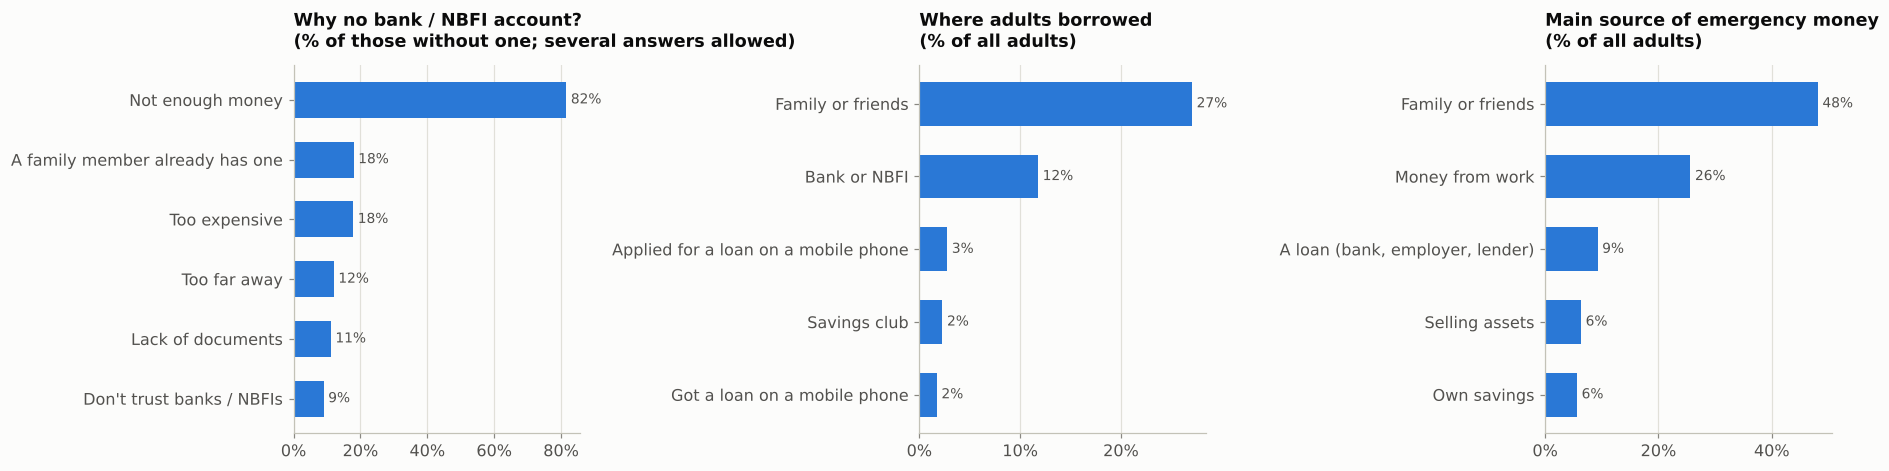

Only 6% of adults would rely on their own savings in an emergency; 48% would turn to family.
60% say raising emergency money within 30 days would be 'very difficult'.


In [8]:
no_fi = 1 - ind("fiaccount.t.d")                       # reasons are asked of adults without a bank / NBFI account
reasons = pd.Series({
    "Not enough money": ind("fin11d"), "A family member already has one": ind("fin11e"), "Too expensive": ind("fin11b"),
    "Too far away": ind("fin11a"), "Lack of documents": ind("fin11c"), "Don't trust banks / NBFIs": ind("fin11f")}) / no_fi
emerg = pd.Series({"Family or friends": ind("fin24fam"), "Money from work": ind("fin24work"), "A loan (bank, employer, lender)": ind("fin24bor"),
                   "Selling assets": ind("fin24sell"), "Own savings": ind("fin24sav")})
borrow = pd.Series({"Family or friends": ind("fin22b"), "Bank or NBFI": ind("fin22a"), "Savings club": ind("fin22c"),
                    "Applied for a loan on a mobile phone": ind("fin20"), "Got a loan on a mobile phone": ind("fin21")})

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
for ax, s, t in [(axes[0], reasons.sort_values(), "Why no bank / NBFI account?\n(% of those without one; several answers allowed)"),
                 (axes[1], borrow.sort_values(), "Where adults borrowed\n(% of all adults)"),
                 (axes[2], emerg.sort_values(), "Main source of emergency money\n(% of all adults)")]:
    ax.barh(s.index, s.values, color=BLUE, height=0.6); bar_labels(ax, horizontal=True); hbar_style(ax)
    ax.set_title(t, fontsize=11.5); ax.xaxis.set_major_formatter(PCT)
fig.tight_layout(); savefig(fig, "A4_reasons_and_coping")

print(f"Only {ind('fin24sav'):.0%} of adults would rely on their own savings in an emergency; {ind('fin24fam'):.0%} would turn to family.")
print(f"{ind('fin24aVD'):.0%} say raising emergency money within 30 days would be 'very difficult'.")

**Reading this:** the main barrier is **income**, not distance or trust — the classic case for low-cost, small-ticket products (mobile wallets,
micro-savings, DPS with tiny instalments). Digital lending is still tiny: only about 2% of adults have received a loan on their phone,
against 27% who borrowed from family. That gap is the fintech-lending opportunity in one number.

## A5. Bangladesh among its peers — country segmentation

Which countries look most like Bangladesh financially, and what does the next group up do differently? We cluster all low- and
middle-income economies on 11 indicators of how adults save, borrow, pay and get online (2024).

In [9]:
PEER_COLS = {"account.t.d": "Any account", "fiaccount.t.d": "Bank/NBFI account", "mobileaccount.t.d": "Mobile money", "save.any.t.d": "Saved",
             "fin17a.17a1.d": "Saved formally", "borrow.any.t.d": "Borrowed", "fin22a": "Borrowed formally", "fin22b": "Borrowed from family",
             "g20.any": "Digital payment", "internet": "Internet use", "fin24aND": "Emergency money: easy"}
lmic = findex[(findex.year == 2024) & (findex.group == "all") & findex.incomegroupwb24.isin(["Low income", "Lower middle income", "Upper middle income"])]
P = lmic.set_index("countrynewwb")[list(PEER_COLS)].copy()
P["mobileaccount.t.d"] = P["mobileaccount.t.d"].fillna(0)            # not reported = no meaningful mobile-money market
P = P.dropna()
ZP = StandardScaler().fit_transform(P)
silP = {k: silhouette_score(ZP, KMeans(k, n_init=20, random_state=SEED).fit_predict(ZP)) for k in range(3, 8)}
print("Silhouette by number of groups:", {k: round(v, 3) for k, v in silP.items()})
K_P = 4
kmP = KMeans(K_P, n_init=20, random_state=SEED).fit(ZP)
P["cluster"] = kmP.labels_
cp = P.groupby("cluster")[list(PEER_COLS)].mean()

def name_peer_clusters(cp):
    order = cp["account.t.d"].sort_values().index.tolist()
    names = {order[0]: "Largely excluded", order[-1]: "Broad inclusion"}
    mid = order[1:-1]
    mob = cp.loc[mid, "mobileaccount.t.d"] / cp.loc[mid, "account.t.d"]
    names[mob.idxmax()] = "Mobile-money led"
    names[mob.idxmin()] = "Bank-led, partial"
    return names

ORDER_P = ["Largely excluded", "Bank-led, partial", "Mobile-money led", "Broad inclusion"]
P["group"] = P["cluster"].map(name_peer_clusters(cp))
bd_group = P.loc["Bangladesh", "group"]
d_bd = pd.Series(np.linalg.norm(ZP - ZP[P.index.get_loc("Bangladesh")], axis=1), index=P.index).drop("Bangladesh").sort_values()
print(f"Bangladesh is in the '{bd_group}' group ({(P.group == bd_group).sum()} countries).")
print("Five most similar countries:", ", ".join(d_bd.index[:5]))

prof_P = P.groupby("group")[list(PEER_COLS)].mean().reindex(ORDER_P)
prof_P.loc["Bangladesh"] = P.loc["Bangladesh", list(PEER_COLS)]
prof_P.insert(0, "countries", P.group.value_counts().reindex(ORDER_P).tolist() + [1])
prof_P.rename(columns=PEER_COLS).style.format("{:.0%}", subset=list(PEER_COLS.values())).format("{:.0f}", subset=["countries"])

Silhouette by number of groups: {3: 0.288, 4: 0.251, 5: 0.249, 6: 0.252, 7: 0.239}


Bangladesh is in the 'Largely excluded' group (18 countries).
Five most similar countries: Egypt, Arab Rep., Comoros, Morocco, Cambodia, Nepal


,countries,Any account,Bank/NBFI account,Mobile money,Saved,Saved formally,Borrowed,Borrowed formally,Borrowed from family,Digital payment,Internet use,Emergency money: easy
group,,,,,,,,,,,,
Largely excluded,18,38%,27%,21%,43%,17%,70%,6%,44%,30%,39%,12%
"Bank-led, partial",26,47%,45%,11%,37%,16%,48%,8%,25%,36%,79%,20%
Mobile-money led,21,64%,30%,55%,65%,39%,72%,7%,46%,61%,44%,14%
Broad inclusion,27,82%,81%,21%,51%,33%,53%,13%,26%,70%,82%,27%
Bangladesh,1,43%,33%,21%,20%,11%,70%,12%,27%,34%,44%,7%


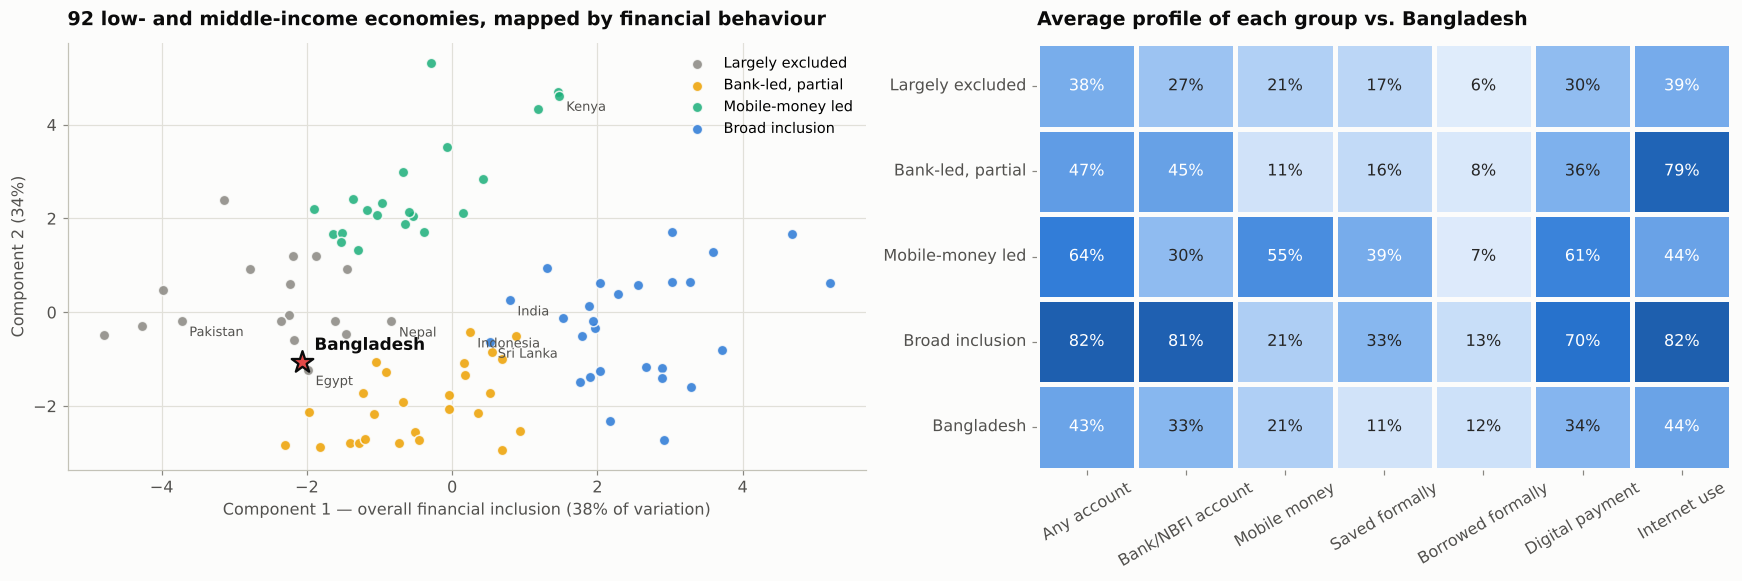

In [10]:
pca = PCA(2, random_state=SEED).fit(ZP); XY = pca.transform(ZP)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
for g, c in zip(ORDER_P, [MUTED, YELLOW, AQUA, BLUE]):
    m = (P.group == g).values
    ax.scatter(XY[m, 0], XY[m, 1], s=46, color=c, alpha=0.85, edgecolor=SURFACE, linewidth=1, label=g)
i = P.index.get_loc("Bangladesh")
ax.scatter(XY[i, 0], XY[i, 1], s=220, color=RED, edgecolor=INK, linewidth=1.5, zorder=5, marker="*")
ax.annotate("Bangladesh", XY[i], xytext=(8, 8), textcoords="offset points", fontsize=11, fontweight="bold", color=INK)
for ctry in ["India", "Pakistan", "Nepal", "Sri Lanka", "Kenya", "Indonesia", "Vietnam", "Egypt, Arab Rep."]:
    if ctry in P.index:
        j = P.index.get_loc(ctry); ax.annotate(ctry.replace(", Arab Rep.", ""), XY[j], xytext=(5, -10), textcoords="offset points", fontsize=8.5, color=INK2)
ax.set_title(f"{len(P)} low- and middle-income economies, mapped by financial behaviour")
ax.set_xlabel(f"Component 1 — overall financial inclusion ({pca.explained_variance_ratio_[0]:.0%} of variation)")
ax.set_ylabel(f"Component 2 ({pca.explained_variance_ratio_[1]:.0%})"); ax.legend(loc="best"); ax.grid(axis="x")
ax = axes[1]
show = ["Any account", "Bank/NBFI account", "Mobile money", "Saved formally", "Borrowed formally", "Digital payment", "Internet use"]
hm = prof_P.rename(columns=PEER_COLS)[show]
sns.heatmap(hm, annot=True, fmt=".0%", cmap=BLUES, vmin=0, vmax=1, linewidths=2, linecolor=SURFACE, cbar=False, ax=ax)
ax.set_title("Average profile of each group vs. Bangladesh"); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); savefig(fig, "A5_peer_groups")

## A6. The Inclusion-Gap model — how far behind *should* Bangladesh be?

The fair comparison is not "Bangladesh vs. India" but **"Bangladesh vs. what a country with Bangladesh's phones, internet and digital
skills normally achieves."** We train a model on every economy in Findex 2024 — 1,900+ rows of country × population group — that predicts
account ownership from *readiness* only: phone ownership, smartphone use, internet use, SIM registered in own name, ability to read and send
a text message, plus region and income level. Outcomes such as saving or borrowing are deliberately **left out**, so the model can't cheat.

**Honest validation:** leave-country-out cross-validation — Bangladesh's prediction comes from a model that never saw Bangladesh.
**Robustness:** 8 versions (two feature sets × with/without group labels × gradient boosting / linear regression). The gap is reported as the
average of all eight, with the full range.

In [11]:
G = findex[(findex.year == 2024) & findex.incomegroupwb24.notna() & findex["account.t.d"].notna()].copy()
READY_A = ["con1", "internet", "con9a"]
READY_B = READY_A + ["con11", "con14", "con16"]
NICE = {"con1": "Owns a mobile phone", "internet": "Uses the internet", "con9a": "Main phone is a smartphone",
        "con11": "SIM registered in own name", "con14": "Can read a text message", "con16": "Can send a text message"}

def design(df, feats, use_seg, linear):
    X = df[feats].copy()
    if linear:
        X = X.fillna(G[feats].mean())
        parts = [X, pd.get_dummies(df.incomegroupwb24, prefix="inc", dtype=float), pd.get_dummies(df.regionwb24_hi, prefix="reg", dtype=float)]
        if use_seg: parts.append(pd.get_dummies(df.group2, prefix="seg", dtype=float))
        return pd.concat(parts, axis=1)
    X["region"] = df.regionwb24_hi.astype("category"); X["income"] = df.incomegroupwb24.astype("category")
    if use_seg: X["segment"] = df.group2.astype("category")
    return X

y_g, groups_g = G["account.t.d"].values, G["codewb"].values
specs, preds = [], {}
for fname, feats in [("phone+internet", READY_A), ("+digital skills", READY_B)]:
    for use_seg in [False, True]:
        for kind in ["Gradient boosting", "Linear"]:
            X = design(G, feats, use_seg, kind == "Linear")
            oof = np.zeros(len(G))
            for tr, te in GroupKFold(n_splits=5).split(X, y_g, groups_g):
                mdl = (LinearRegression() if kind == "Linear" else
                       lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=15, min_child_samples=20, subsample=0.8,
                                         subsample_freq=1, colsample_bytree=0.8, random_state=SEED, verbose=-1))
                mdl.fit(X.iloc[tr], y_g[tr]); oof[te] = np.clip(mdl.predict(X.iloc[te]), 0, 1)
            key = f"{kind} · {fname} · {'with' if use_seg else 'no'} group label"
            preds[key] = oof
            specs.append({"model": key, "R² (unseen countries)": r2_score(y_g, oof), "MAE (points)": 100 * mean_absolute_error(y_g, oof)})
specs = pd.DataFrame(specs)
specs.style.format({"R² (unseen countries)": "{:.2f}", "MAE (points)": "{:.1f}"}).hide(axis="index")

model,R² (unseen countries),MAE (points)
Gradient boosting · phone+internet · no group label,0.54,12.3
Linear · phone+internet · no group label,0.55,12.3
Gradient boosting · phone+internet · with group label,0.56,12.1
Linear · phone+internet · with group label,0.57,11.9
Gradient boosting · +digital skills · no group label,0.56,11.9
Linear · +digital skills · no group label,0.57,11.9
Gradient boosting · +digital skills · with group label,0.58,11.7
Linear · +digital skills · with group label,0.58,11.5


Bangladesh: actual 43% vs expected 73% → gap -30 points (range across 8 models: -35 to -21)
That is roughly 36 million 'missing' accounts.


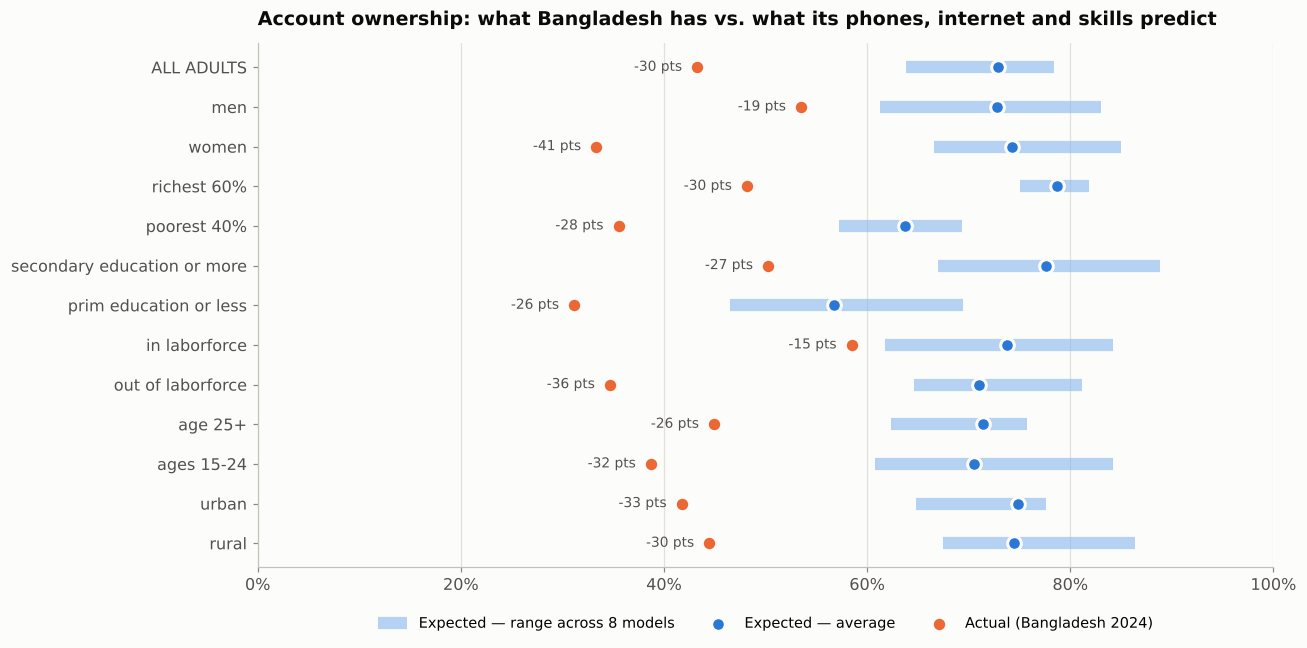

,actual,expected,expected_low,expected_high,gap,missing accounts (M)
segment,,,,,,
all,43%,73%,64%,78%,-30 pts,36.4
men,54%,73%,61%,83%,-19 pts,11.7
women,33%,74%,67%,85%,-41 pts,25.5
richest 60%,48%,79%,75%,82%,-30 pts,22.9
poorest 40%,36%,64%,57%,69%,-28 pts,13.5
secondary edu or more,50%,78%,67%,89%,-27 pts,21.3
prim edu or less,31%,57%,46%,69%,-26 pts,11.5
in laborforce,58%,74%,62%,84%,-15 pts,6.8
out of laborforce,35%,71%,65%,81%,-36 pts,28.5


In [12]:
E = pd.DataFrame(preds); E["actual"] = y_g; E["country"] = groups_g; E["segment"] = G["group2"].values
bd = E[E.country == "BGD"].set_index("segment")
pcols = list(preds)
gapdf = pd.DataFrame({"actual": bd["actual"], "expected": bd[pcols].mean(axis=1),
                      "expected_low": bd[pcols].min(axis=1), "expected_high": bd[pcols].max(axis=1)})
gapdf["gap"] = gapdf["actual"] - gapdf["expected"]
gapdf["missing accounts (M)"] = [-gapdf.loc[s, "gap"] * N * (1 if s == "all" else SHARE.get(s, np.nan)) / 1e6 for s in gapdf.index]
order_seg = ["all", "men", "women", "richest 60%", "poorest 40%", "secondary edu or more", "prim edu or less",
             "in laborforce", "out of laborforce", "age 25+", "ages 15-24", "urban", "rural"]
gapdf = gapdf.reindex([s for s in order_seg if s in gapdf.index])
GAP_ALL = float(gapdf.loc["all", "gap"]); GAP_LO = float(gapdf.loc["all", "actual"] - gapdf.loc["all", "expected_high"])
GAP_HI = float(gapdf.loc["all", "actual"] - gapdf.loc["all", "expected_low"])
print(f"Bangladesh: actual {gapdf.loc['all','actual']:.0%} vs expected {gapdf.loc['all','expected']:.0%} "
      f"→ gap {GAP_ALL*100:+.0f} points (range across 8 models: {GAP_LO*100:+.0f} to {GAP_HI*100:+.0f})")
print(f"That is roughly {gapdf.loc['all','missing accounts (M)']:.0f} million 'missing' accounts.")

fig, ax = plt.subplots(figsize=(12, 6))
ypos = np.arange(len(gapdf))[::-1]
ax.hlines(ypos, gapdf["expected_low"], gapdf["expected_high"], color=LIGHTBLUE, lw=8, alpha=0.6, label="Expected — range across 8 models")
ax.scatter(gapdf["expected"], ypos, s=80, color=BLUE, zorder=3, label="Expected — average", edgecolor=SURFACE, linewidth=2)
ax.scatter(gapdf["actual"], ypos, s=90, color=ORANGE, zorder=4, label="Actual (Bangladesh 2024)", edgecolor=SURFACE, linewidth=2)
for yy, (s, r) in zip(ypos, gapdf.iterrows()):
    ax.annotate(f"{r.gap*100:+.0f} pts", (min(r.actual, r.expected_low), yy), xytext=(-10, 0), textcoords="offset points", ha="right", va="center", fontsize=9, color=INK2)
ax.set_yticks(ypos); ax.set_yticklabels([s.replace("edu", "education").replace("all", "ALL ADULTS") for s in gapdf.index])
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(PCT); hbar_style(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=3)
ax.set_title("Account ownership: what Bangladesh has vs. what its phones, internet and skills predict")
fig.tight_layout(); savefig(fig, "A6_inclusion_gap")
gapdf.style.format({"actual": "{:.0%}", "expected": "{:.0%}", "expected_low": "{:.0%}", "expected_high": "{:.0%}",
                    "gap": lambda v: f"{v*100:+.0f} pts", "missing accounts (M)": "{:.1f}"})

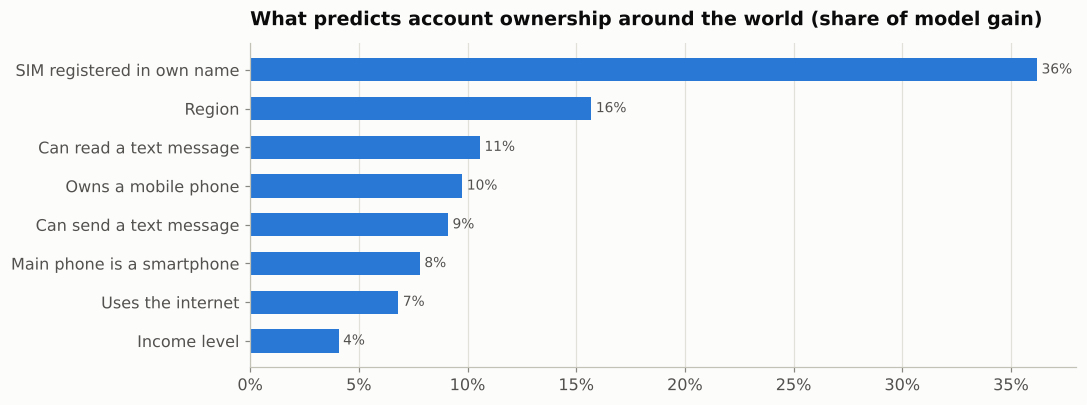

In [13]:
best_key = specs.sort_values("R² (unseen countries)", ascending=False)["model"].iloc[0]
Xg = design(G, READY_B, False, False)
gbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=15, min_child_samples=20, subsample=0.8, subsample_freq=1,
                        colsample_bytree=0.8, random_state=SEED, verbose=-1).fit(Xg, y_g)
imp = pd.Series(gbm.booster_.feature_importance("gain"), index=Xg.columns)
imp = (imp / imp.sum()).rename(NICE | {"region": "Region", "income": "Income level"}).sort_values()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6); bar_labels(ax, horizontal=True); hbar_style(ax); ax.xaxis.set_major_formatter(PCT)
ax.set_title("What predicts account ownership around the world (share of model gain)")
fig.tight_layout(); savefig(fig, "A7_gap_model_drivers")

### What Part A tells a bank, NBFI or MFS company

1. **Bangladesh has the phones but not the accounts.** Given its connectivity, Bangladesh "should" have far higher account ownership —
   every one of the 8 models agrees the gap is large. The gap is widest for **women** and for adults **outside the labour force**.
2. **The 2021–24 fall is a usage problem.** Millions of people stopped *using* accounts. Re-activation (cheaper cash-out, interest on wallet
   balances, salary and allowance payments into accounts) is cheaper than acquisition.
3. **Credit demand is huge and informal.** Seven in ten adults borrowed; about one in eight borrowed formally. Small, fast, phone-based credit
   is the obvious bridge — and still reaches only around 2% of adults.
4. **Income, not distance, is the barrier.** Products must work at very small ticket sizes.

---
# PART B — Institutions: Bangladesh's listed banks and NBFIs

The people in Part A are served by banks, NBFIs and MFS providers. Part B looks at the **36 listed banks and 23 listed NBFIs** on the Dhaka
Stock Exchange. Share prices are the market's running, money-backed opinion of each institution's health; company data adds the DSE category
(**A** = regular dividends, **B** = irregular, **Z** = no dividend / AGM failures — the exchange's own "distress" flag), shareholding, reserves
and dividend history.

## B1. Building the universe and the health signals

In [14]:
fund_now = fund[fund.snapshot_date == fund.snapshot_date.max()].drop_duplicates("symbol").set_index("symbol")
EXCLUDE = ["Mutual Funds", "Corporate Bond", "Debenture", "Treasury Bond"]
equities = fund_now[~fund_now.sector.isin(EXCLUDE) & fund_now.market_category.isin(["A", "B", "Z"])].copy()
FIN_SECTORS = ["Bank", "Financial Institutions"]
print("Listed equities analysed:", len(equities), "| categories:", equities.market_category.value_counts().to_dict())
print("Banks:", (equities.sector == "Bank").sum(), "| NBFIs:", (equities.sector == "Financial Institutions").sum())

px_long = prices[prices.symbol.isin(equities.index)].copy()
px_long["close"] = px_long["close"].where(px_long["close"] > 0, px_long["ycp"])   # no trade that day → yesterday's close
PX = px_long.pivot_table(index="date", columns="symbol", values="close").sort_index().ffill()
VAL = px_long.pivot_table(index="date", columns="symbol", values="value").sort_index()     # traded value, BDT million
VOL = px_long.pivot_table(index="date", columns="symbol", values="volume").sort_index()

def dividend_years(text, first=2021, last=2025):
    yrs = {int(y) for y in re.findall(r"(20\d\d)", str(text))}
    return sum(y in yrs for y in range(first, last + 1))

def health_features(end=None, window=250):
    """Market + balance-sheet health signals for every listed equity, using only data up to `end`."""
    P = PX if end is None else PX[PX.index <= end]
    V = VAL.reindex(P.index); Q = VOL.reindex(P.index)
    P = P.iloc[-window:]; V = V.iloc[-window:]; Q = Q.iloc[-window:]
    R = P.pct_change(fill_method=None).clip(-0.5, 0.5); mkt = R.mean(axis=1)
    F = pd.DataFrame(index=P.columns)
    F["return_1y"] = P.iloc[-1] / P.iloc[0] - 1
    F["return_3m"] = P.iloc[-1] / P.iloc[-63] - 1
    F["volatility"] = R.std() * np.sqrt(250)
    F["max_drawdown"] = (P / P.cummax() - 1).min()
    F["below_peak"] = P.iloc[-1] / P.max() - 1
    F["beta"] = R.apply(lambda r: r.cov(mkt) / mkt.var())
    F["log_turnover"] = np.log1p(V.mean())
    F["price_to_face"] = (P.iloc[-1] / equities.face_value.replace(0, np.nan)).clip(upper=100)
    F["days_traded_60d"] = (Q.iloc[-60:].fillna(0) > 0).mean()
    return F

H = health_features()
H = H.join(equities[["sector", "market_category", "market_cap_mn", "sponsor_pct", "institute_pct", "foreign_pct"]])
H["log_mcap"] = np.log(H["market_cap_mn"])
H["reserve_to_capital"] = (equities.reserve_mn / equities.paid_up_capital_mn).clip(-5, 5)
H["dividend_years_5"] = equities.cash_dividend.map(dividend_years)
H["Z"] = (H.market_category == "Z").astype(int)
H = H.dropna(subset=["return_1y", "volatility", "price_to_face"])
H["suspended"] = H["days_traded_60d"] < 0.2
print(f"Health table: {len(H)} companies · {int(H.suspended.sum())} with almost no trading in the last 60 days (suspended / delisting).")
FIN = H[H.sector.isin(FIN_SECTORS)].copy()
MERGED = ["FIRSTSBANK", "GIB", "SIBL", "EXIMBANK", "UNIONBANK"]       # merged into Sammilito Islami Bank (Nov–Dec 2025), shares written to zero
print("Suspended financial institutions:", ", ".join(FIN.index[FIN.suspended]))
print(f"Banks with complete data: {(FIN.sector == 'Bank').sum()} · NBFIs: {(FIN.sector == 'Financial Institutions').sum()}")

Listed equities analysed: 359 | categories: {'A': 160, 'Z': 125, 'B': 74}
Banks: 36 | NBFIs: 23


Health table: 357 companies · 7 with almost no trading in the last 60 days (suspended / delisting).
Suspended financial institutions: EXIMBANK, FIRSTSBANK, GIB, SIBL, UNIONBANK
Banks with complete data: 35 · NBFIs: 23


In [15]:
summary_fin = (FIN.groupby("sector").agg(institutions=("Z", "size"), in_Z=("Z", "mean"),
                                          below_face_value=("price_to_face", lambda s: (s < 1).mean()),
                                          negative_reserves=("reserve_to_capital", lambda s: (s < 0).mean()),
                                          paid_cash_dividend_all_5y=("dividend_years_5", lambda s: (s == 5).mean()),
                                          median_return_1y=("return_1y", "median")))
summary_fin.style.format({"in_Z": "{:.0%}", "below_face_value": "{:.0%}", "negative_reserves": "{:.0%}",
                          "paid_cash_dividend_all_5y": "{:.0%}", "median_return_1y": "{:+.0%}"})

,institutions,in_Z,below_face_value,negative_reserves,paid_cash_dividend_all_5y,median_return_1y
sector,,,,,,
Bank,35,49%,46%,14%,40%,-10%
Financial Institutions,23,70%,57%,61%,17%,+6%


**Reading this:** a share trading **below its face value of Tk 10** means investors think the company is worth less than the money shareholders
originally put in. **Negative reserves** mean accumulated losses have eaten into capital. Both are far more common among NBFIs than banks —
the long tail of Bangladesh's NBFI sector is in deep trouble, while a handful of leaders (IDLC, IPDC, DBH, National Housing, United Finance) stay healthy.

## B2. Lender personas — grouping the 59 institutions
K-Means on eight health signals, run on institutions that are still trading. The five merged banks are shown separately.

In [16]:
SEG_B = ["return_1y", "volatility", "max_drawdown", "price_to_face", "reserve_to_capital", "dividend_years_5", "log_mcap", "log_turnover"]
ACT = FIN[~FIN.suspended].copy()
ZB = StandardScaler().fit_transform(ACT[SEG_B].assign(price_to_face=np.log(ACT.price_to_face)))
silB = {k: silhouette_score(ZB, KMeans(k, n_init=20, random_state=SEED).fit_predict(ZB)) for k in range(3, 7)}
print("Silhouette by number of personas:", {k: round(v, 3) for k, v in silB.items()})
K_B = 4
kmB = KMeans(K_B, n_init=20, random_state=SEED).fit(ZB)
ACT["cluster"] = kmB.labels_
zc = pd.DataFrame(ZB, index=ACT.index, columns=SEG_B).groupby(ACT["cluster"]).mean()
health = zc["price_to_face"] + zc["reserve_to_capital"] + zc["dividend_years_5"] + zc["max_drawdown"]
names_B = dict(zip(health.sort_values(ascending=False).index, ["Sector Leaders", "Weak Mid-tier", "Distressed", "Distressed, speculative trading"]))
ACT["persona"] = ACT["cluster"].map(names_B)
FIN["persona"] = ACT["persona"]
FIN.loc[FIN.index.isin(MERGED), "persona"] = "Merged 2025 (shares written to zero)"
FIN["persona"] = FIN["persona"].fillna("Suspended")
ORDER_B = ["Sector Leaders", "Weak Mid-tier", "Distressed", "Distressed, speculative trading", "Merged 2025 (shares written to zero)"]
COLOR_B = dict(zip(ORDER_B, [BLUE, AQUA, YELLOW, ORANGE, RED]))

pers = (FIN.groupby("persona").agg(institutions=("Z", "size"), banks=("sector", lambda s: (s == "Bank").sum()),
                                    nbfis=("sector", lambda s: (s == "Financial Institutions").sum()),
                                    price_to_face=("price_to_face", "median"), reserve_to_capital=("reserve_to_capital", "median"),
                                    dividend_years=("dividend_years_5", "median"), return_1y=("return_1y", "median"),
                                    max_drawdown=("max_drawdown", "median"), share_in_Z=("Z", "mean"))
        .reindex([p for p in ORDER_B if p in FIN.persona.unique()]))
pers["members"] = [", ".join(FIN.index[FIN.persona == p].tolist()) for p in pers.index]
pers.style.format({"price_to_face": "{:.2f}×", "reserve_to_capital": "{:.2f}", "dividend_years": "{:.0f}/5", "return_1y": "{:+.0%}",
                   "max_drawdown": "{:.0%}", "share_in_Z": "{:.0%}"})

Silhouette by number of personas: {3: 0.344, 4: 0.322, 5: 0.303, 6: 0.227}


,institutions,banks,nbfis,price_to_face,reserve_to_capital,dividend_years,return_1y,max_drawdown,share_in_Z,members
persona,,,,,,,,,,
Sector Leaders,22,16,6,2.42×,1.73,5/5,+3%,-21%,5%,"BANKASIA, BRACBANK, CITYBANK, DBH, DHAKABANK, DUTCHBANGL, EBL, ICB, IDLC, IPDC, ISLAMIBANK, JAMUNABANK, MIDLANDBNK, NCCBANK, NHFIL, PRIMEBANK, PUBALIBANK, SHAHJABANK, SOUTHEASTB, TRUSTBANK, UNITEDFIN, UTTARABANK"
Weak Mid-tier,16,12,4,0.89×,0.65,2/5,-13%,-31%,88%,"ALARABANK, BDFINANCE, IFIC, ISLAMICFIN, LANKABAFIN, MERCANBANK, MTB, NBL, NRBCBANK, ONEBANKPLC, PREMIERBAN, RUPALIBANK, SBACBANK, STANDBANKL, UCB, UTTARAFIN"
Distressed,9,2,7,0.32×,-3.20,0/5,+0%,-42%,100%,"ABBANK, BAYLEASING, BIFC, GSPFINANCE, ICBIBANK, MIDASFIN, PHOENIXFIN, PRIMEFIN, UNIONCAP"
"Distressed, speculative trading",6,0,6,0.21×,-5.00,0/5,+65%,-75%,100%,"FAREASTFIN, FASFIN, FIRSTFIN, ILFSL, PLFSL, PREMIERLEA"
Merged 2025 (shares written to zero),5,5,0,0.19×,0.82,2/5,-14%,-38%,60%,"EXIMBANK, FIRSTSBANK, GIB, SIBL, UNIONBANK"


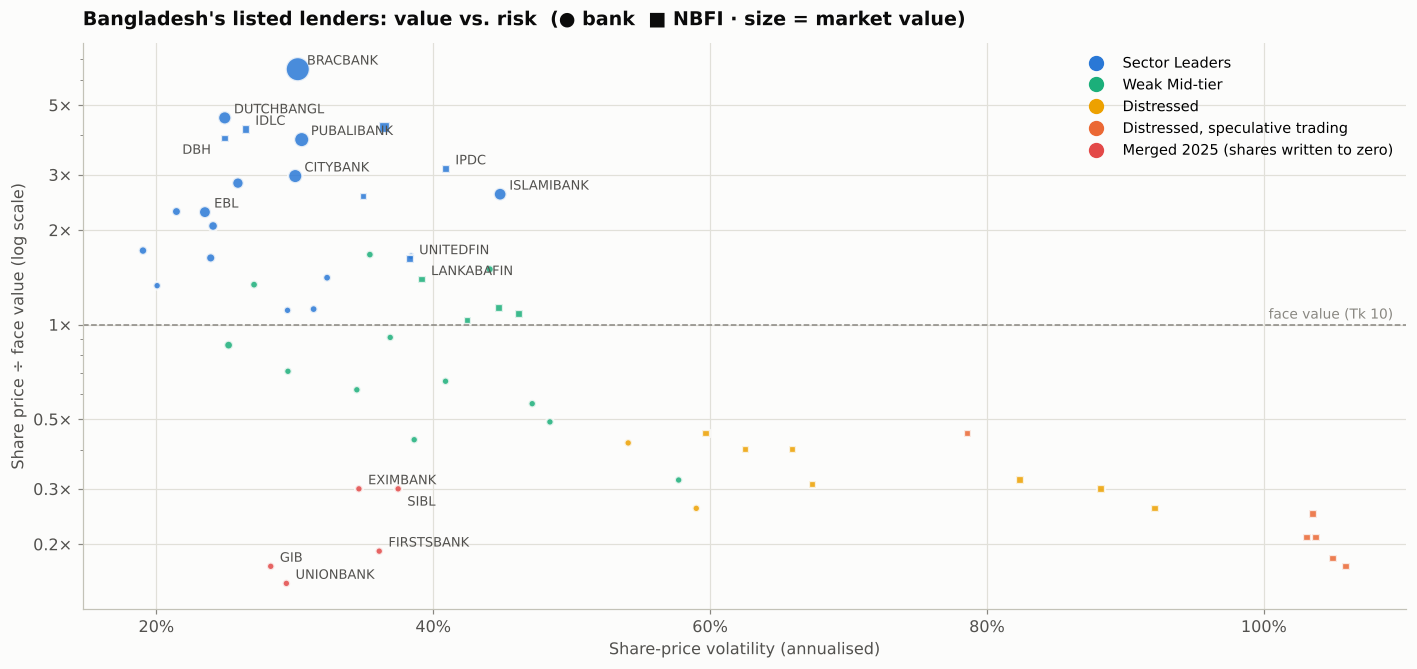

In [17]:
fig, ax = plt.subplots(figsize=(13, 6.2))
for p in ORDER_B:
    d = FIN[FIN.persona == p]
    for sec, mk in [("Bank", "o"), ("Financial Institutions", "s")]:
        dd = d[d.sector == sec]
        ax.scatter(dd["volatility"], dd["price_to_face"], s=np.clip(dd["market_cap_mn"] / 600, 25, 400), marker=mk, color=COLOR_B[p],
                   alpha=0.85, edgecolor=SURFACE, linewidth=1.5, label=p if sec == "Bank" else None)
ax.set_yscale("log"); ax.axhline(1, color=MUTED, ls="--", lw=1)
ax.text(ax.get_xlim()[1] if False else 0.99, 1.02, "face value (Tk 10)", transform=ax.get_yaxis_transform(), ha="right", va="bottom", color=MUTED, fontsize=9)
for s in ["IDLC", "IPDC", "BRACBANK", "CITYBANK", "DUTCHBANGL", "EBL", "PUBALIBANK", "ISLAMIBANK", "LANKABAFIN", "DBH", "UNITEDFIN"] + MERGED:
    if s in FIN.index:
        ax.annotate(s, (FIN.loc[s, "volatility"], FIN.loc[s, "price_to_face"]), xytext={"SIBL": (6, -11), "DBH": (-28, -10)}.get(s, (6, 3)),
                    textcoords="offset points", fontsize=8.5, color=INK2)
ax.yaxis.set_major_locator(mtick.FixedLocator([0.2, 0.3, 0.5, 1, 2, 3, 5]))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}×")); ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Share-price volatility (annualised)"); ax.set_ylabel("Share price ÷ face value (log scale)")
ax.set_title("Bangladesh's listed lenders: value vs. risk  (● bank  ■ NBFI · size = market value)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], marker="o", ls="", ms=9, color=COLOR_B[p], label=p) for p in ORDER_B], loc="upper right"); ax.grid(axis="x")
fig.tight_layout(); savefig(fig, "B1_lender_map")

**Reading the personas.** *Sector Leaders* pay a cash dividend every year and trade well above face value — this is where IDLC, IPDC, DBH,
BRAC, City, Dutch-Bangla and Eastern sit. *Weak Mid-tier* lenders still trade near face value but mostly stopped paying dividends.
*Distressed* lenders trade at around a third of face value with reserves wiped out. The last group is the strangest: equally broken
balance sheets, yet share prices that **rose** strongly with extreme volatility — classic speculative trading in "junk" shares, not recovery.

## B3. The Early-Warning model — can market data spot distress?

**Idea:** the DSE's Z category is an official distress label. We train a model on **all non-financial listed companies** (textiles, pharma,
engineering…) to recognise what a Z company looks like from its share-price behaviour, ownership and reserves, then **apply it to banks and NBFIs,
which it never saw.** Dividend history is excluded, because the Z rule is partly defined by it.

In [18]:
EW = ["return_1y", "return_3m", "volatility", "max_drawdown", "below_peak", "beta", "log_turnover", "price_to_face",
      "log_mcap", "reserve_to_capital", "sponsor_pct", "institute_pct", "foreign_pct"]
TRAIN = H[~H.sector.isin(FIN_SECTORS) & ~H.suspended]
TEST = H[H.sector.isin(FIN_SECTORS)]
med = TRAIN[EW].median()
ew_models = {"Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.5)),
             "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=10,
                                            subsample=0.8, subsample_freq=1, random_state=SEED, verbose=-1)}
cvB = StratifiedKFold(5, shuffle=True, random_state=SEED)
rows = []
for name, mdl in ew_models.items():
    oof = cross_val_predict(mdl, TRAIN[EW].fillna(med), TRAIN.Z, cv=cvB, method="predict_proba")[:, 1]
    mdl.fit(TRAIN[EW].fillna(med), TRAIN.Z)
    p_fin = mdl.predict_proba(TEST[EW].fillna(med))[:, 1]
    rows.append({"model": name, "CV AUC (non-financial firms)": roc_auc_score(TRAIN.Z, oof),
                 "AUC on banks & NBFIs (never seen)": roc_auc_score(TEST.Z, p_fin)})
    FIN[f"p_{name}"] = p_fin
ew_res = pd.DataFrame(rows).set_index("model")
FIN["distress_score"] = FIN[[f"p_{m}" for m in ew_models]].mean(axis=1)
ew_res.style.format("{:.3f}")

,CV AUC (non-financial firms),AUC on banks & NBFIs (never seen)
model,,
Logistic regression,0.975,0.952
LightGBM,0.986,0.939


WATCHLIST — not in Z, but look like Z to the model: none
RECOVERY CANDIDATES — in Z, but look healthy: UCB (3%), ISLAMIBANK (6%), ONEBANKPLC (12%), IFIC (25%)


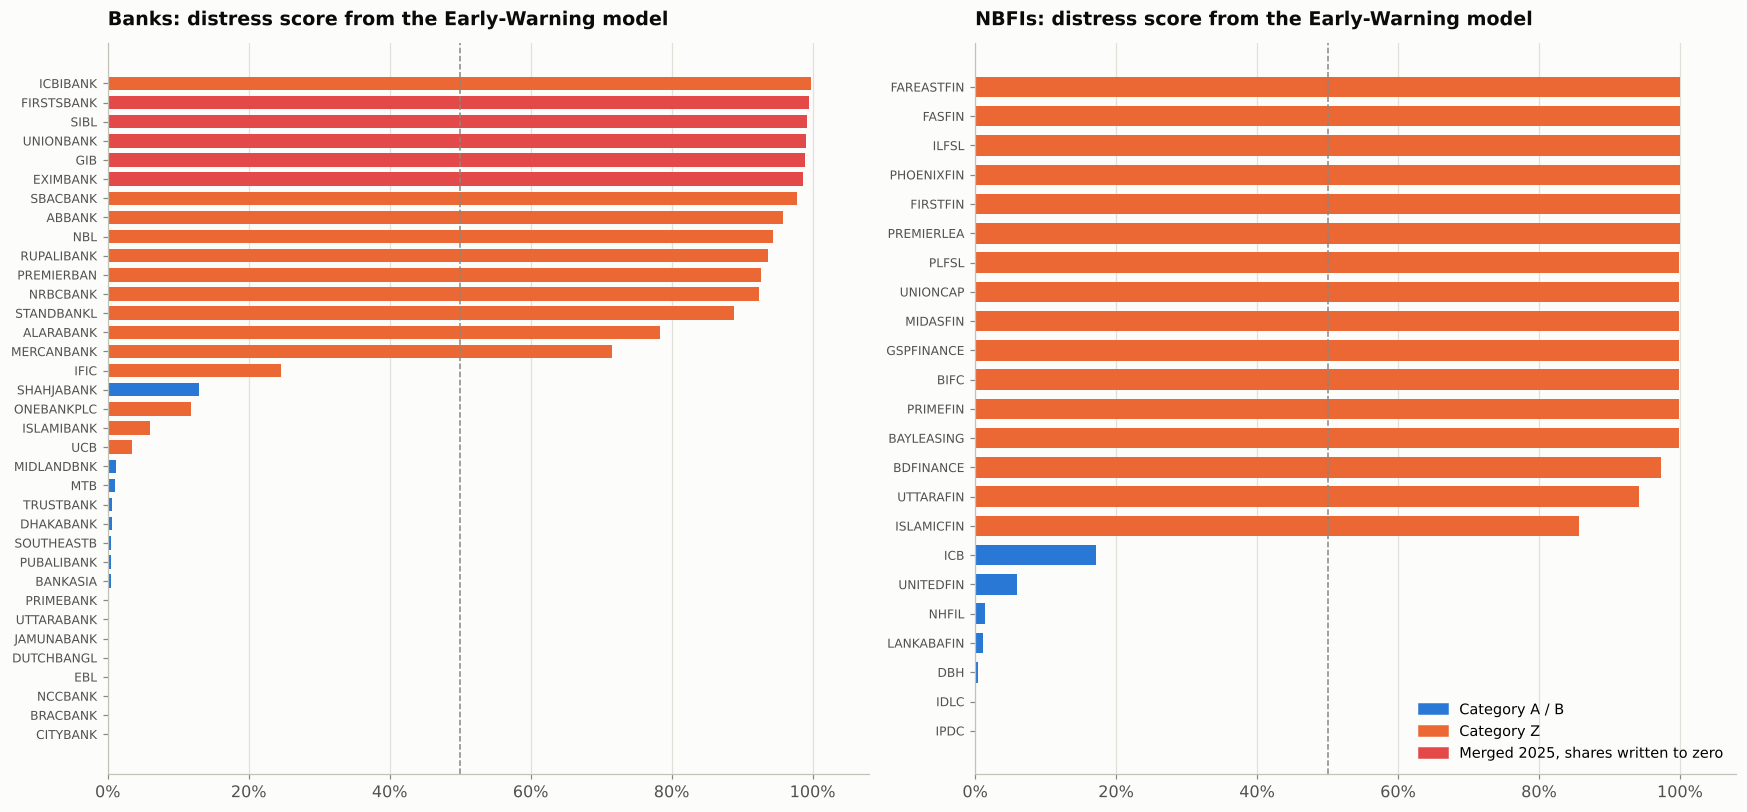

In [19]:
watch = FIN[(FIN.market_category != "Z") & (FIN.distress_score >= 0.5) & ~FIN.suspended].sort_values("distress_score", ascending=False)
recover = FIN[(FIN.market_category == "Z") & (FIN.distress_score < 0.3) & ~FIN.suspended].sort_values("distress_score")
print("WATCHLIST — not in Z, but look like Z to the model:", ", ".join(f"{s} ({v:.0%})" for s, v in watch.distress_score.items()) or "none")
print("RECOVERY CANDIDATES — in Z, but look healthy:", ", ".join(f"{s} ({v:.0%})" for s, v in recover.distress_score.items()) or "none")

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
for ax, sec, title in [(axes[0], "Bank", "Banks"), (axes[1], "Financial Institutions", "NBFIs")]:
    d = FIN[FIN.sector == sec].sort_values("distress_score")
    cols = [RED if s in MERGED else (ORANGE if c == "Z" else BLUE) for s, c in zip(d.index, d.market_category)]
    ax.barh(d.index, d.distress_score, color=cols, height=0.7); hbar_style(ax); ax.xaxis.set_major_formatter(PCT)
    ax.axvline(0.5, color=MUTED, ls="--", lw=1); ax.set_xlim(0, 1.08); ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"{title}: distress score from the Early-Warning model")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=BLUE, label="Category A / B"), Patch(color=ORANGE, label="Category Z"),
                        Patch(color=RED, label="Merged 2025, shares written to zero")], loc="lower right")
fig.tight_layout(); savefig(fig, "B2_distress_scores")

## B4. The real-world test — would this have seen the 2025 bank collapse coming?

On **9 November 2025** Bangladesh Bank approved merging five troubled Islamic banks — First Security Islami, Global Islami, Social Islami
(SIBL), EXIM and Union — into the new Sammilito Islami Bank, and in December 2025 ordered their shares written down to **zero**.

**The test:** rebuild the model using **only share prices up to 30 September 2025** — nearly six weeks before the decision — with no balance-sheet
or ownership data (those snapshots are from 2026). Train it on non-financial companies only. Then rank every listed bank.

Ranks of the five merged banks among 35 banks (1 = most distressed), using data up to 2025-09-30:
{'UNIONBANK': 1, 'GIB': 2, 'FIRSTSBANK': 3, 'SIBL': 4, 'EXIMBANK': 5}
→ All five are inside the model's top 5. Probability of that happening by chance: 1 in 324,632.


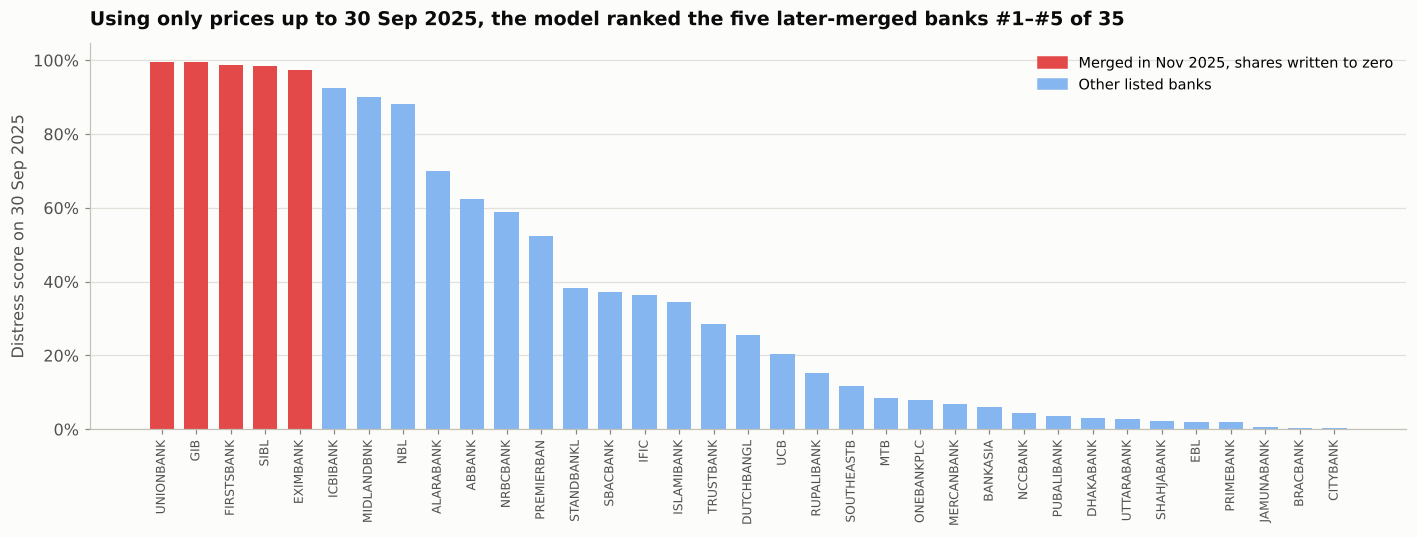

In [20]:
CUTOFF = "2025-09-30"
H0 = health_features(end=CUTOFF).join(equities[["sector", "market_category"]]).dropna(subset=["return_1y", "volatility", "price_to_face"])
H0["Z"] = (H0.market_category == "Z").astype(int)
PRICE_ONLY = ["return_1y", "return_3m", "volatility", "max_drawdown", "below_peak", "beta", "log_turnover", "price_to_face"]
tr0 = H0[~H0.sector.isin(FIN_SECTORS)]; banks0 = H0[H0.sector == "Bank"].copy()
m0 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.5)).fit(tr0[PRICE_ONLY].fillna(tr0[PRICE_ONLY].median()), tr0.Z)
banks0["score"] = m0.predict_proba(banks0[PRICE_ONLY].fillna(tr0[PRICE_ONLY].median()))[:, 1]
banks0["rank"] = banks0["score"].rank(ascending=False).astype(int)
ranks = banks0.loc[MERGED, "rank"].sort_values()
n_banks = len(banks0)
top_k = int(ranks.max())
p_chance = comb(n_banks - 5, top_k - 5) / comb(n_banks, top_k) if top_k >= 5 else np.nan   # chance all 5 land in the top-k at random
print(f"Ranks of the five merged banks among {n_banks} banks (1 = most distressed), using data up to {CUTOFF}:")
print(ranks.to_dict())
print(f"→ All five are inside the model's top {top_k}. Probability of that happening by chance: 1 in {1/p_chance:,.0f}.")

fig, ax = plt.subplots(figsize=(13, 5))
d = banks0.sort_values("score", ascending=False)
ax.bar(range(len(d)), d.score, color=[RED if s in MERGED else LIGHTBLUE for s in d.index], width=0.7)
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=90, fontsize=8)
ax.yaxis.set_major_formatter(PCT); ax.set_ylabel("Distress score on 30 Sep 2025")
ax.set_title(f"Using only prices up to 30 Sep 2025, the model ranked the five later-merged banks #{ranks.min()}–#{ranks.max()} of {n_banks}")
ax.legend(handles=[Patch(color=RED, label="Merged in Nov 2025, shares written to zero"), Patch(color=LIGHTBLUE, label="Other listed banks")], loc="upper right")
fig.tight_layout(); savefig(fig, "B3_merger_backtest")

**Be precise about what this proves.** The market had been marking these shares down for months; the model did not discover secret information.
What it shows is that a **simple, systematic early-warning screen**, trained on other industries and given nothing but public prices, would have
put exactly these five banks at the top of a risk list before the regulator acted. For a treasury team placing interbank deposits, an NBFI
choosing which banks to hold money with, or an investor, that is the difference between getting out and getting wiped out.

## B5. NBFI focus — how IDLC and IPDC compare with the sector

In [21]:
nb = FIN[FIN.sector == "Financial Institutions"].copy()
cols_nb = {"price_to_face": "Price ÷ face value", "reserve_to_capital": "Reserves ÷ paid-up capital", "dividend_years_5": "Cash dividends (of last 5 yrs)",
           "return_1y": "1-year share return", "volatility": "Volatility", "max_drawdown": "Worst fall (1 yr)", "distress_score": "Distress score",
           "market_cap_mn": "Market value (Tk mn)"}
nb_tbl = nb[list(cols_nb)].rename(columns=cols_nb).sort_values("Distress score")
nb_tbl.insert(0, "Category", nb.market_category); nb_tbl.insert(1, "Persona", nb.persona)
nb_tbl.style.format({"Price ÷ face value": "{:.2f}×", "Reserves ÷ paid-up capital": "{:.2f}", "Cash dividends (of last 5 yrs)": "{:.0f}",
                     "1-year share return": "{:+.0%}", "Volatility": "{:.0%}", "Worst fall (1 yr)": "{:.0%}", "Distress score": "{:.0%}",
                     "Market value (Tk mn)": "{:,.0f}"}).background_gradient(subset=["Distress score"], cmap="RdBu_r", vmin=0, vmax=1)

,Category,Persona,Price ÷ face value,Reserves ÷ paid-up capital,Cash dividends (of last 5 yrs),1-year share return,Volatility,Worst fall (1 yr),Distress score,Market value (Tk mn)
symbol,,,,,,,,,,
IPDC,A,Sector Leaders,3.13×,0.61,5,+50%,41%,-20%,0%,"15,207"
IDLC,A,Sector Leaders,4.18×,3.48,5,+6%,26%,-18%,0%,"19,661"
DBH,A,Sector Leaders,3.91×,3.93,5,+3%,25%,-16%,0%,"8,094"
LANKABAFIN,A,Weak Mid-tier,1.39×,0.63,3,-17%,39%,-30%,1%,"7,813"
NHFIL,A,Sector Leaders,2.56×,0.71,4,+4%,35%,-23%,1%,"3,373"
UNITEDFIN,A,Sector Leaders,1.62×,0.79,5,+21%,38%,-22%,6%,"3,181"
ICB,B,Sector Leaders,4.23×,1.90,4,-15%,37%,-32%,17%,"33,216"
ISLAMICFIN,Z,Weak Mid-tier,1.03×,-0.76,2,+49%,42%,-24%,86%,"1,487"
UTTARAFIN,Z,Weak Mid-tier,1.13×,4.55,0,-15%,45%,-32%,94%,"1,538"


---
# PART C — Executive Dashboard

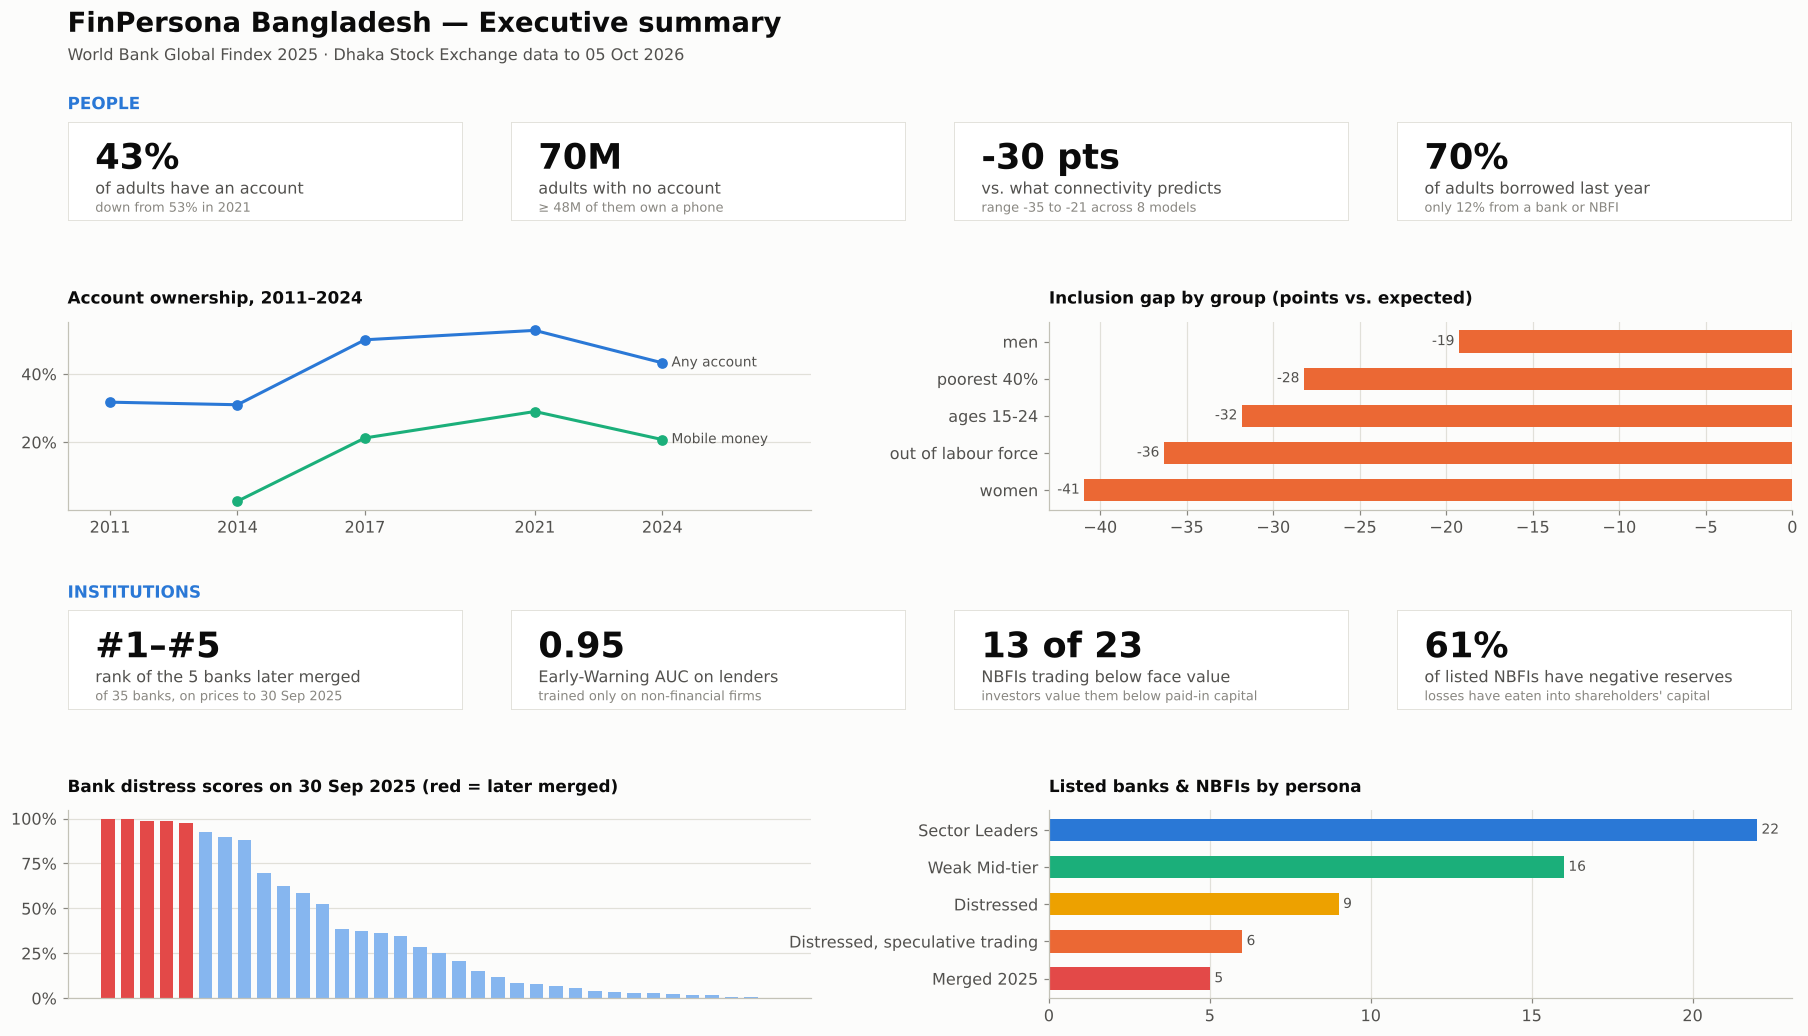

In [22]:
def tile(ax, value, label, sub=""):
    ax.set_axis_off()
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, facecolor="white", edgecolor=GRID, lw=1.2))
    ax.text(0.07, 0.62, value, fontsize=23, fontweight="bold", color=INK, transform=ax.transAxes, va="center")
    ax.text(0.07, 0.32, label, fontsize=10.5, color=INK2, transform=ax.transAxes, va="center")
    ax.text(0.07, 0.13, sub, fontsize=8.5, color=MUTED, transform=ax.transAxes, va="center")

unbanked = (1 - ind("account.t.d")) * N
phone_no_acc = max(ind("con1") - ind("account.t.d"), 0) * N
fin_ew_auc = float(ew_res["AUC on banks & NBFIs (never seen)"].mean())
nbfi_below_face = int((nb.price_to_face < 1).sum())

fig = plt.figure(figsize=(16, 9.6))
gs = fig.add_gridspec(4, 4, height_ratios=[0.9, 1.7, 0.9, 1.7], hspace=0.7, wspace=0.12, left=0.01, right=0.99, top=0.88, bottom=0.05)
fig.text(0.01, 0.985, "FinPersona Bangladesh — Executive summary", fontsize=18, fontweight="bold", color=INK, va="top")
fig.text(0.01, 0.95, f"World Bank Global Findex 2025 · Dhaka Stock Exchange data to {prices.date.max():%d %b %Y}", fontsize=10.5, color=INK2, va="top")
t0 = fig.add_subplot(gs[0, 0]); fig.text(0.01, t0.get_position().y1 + 0.012, "PEOPLE", fontsize=11, fontweight="bold", color=BLUE)
tile(t0, f"{ind('account.t.d'):.0%}", "of adults have an account", f"down from {ind('account.t.d', 2021):.0%} in 2021")
tile(fig.add_subplot(gs[0, 1]), f"{unbanked/1e6:.0f}M", "adults with no account", f"≥ {phone_no_acc/1e6:.0f}M of them own a phone")
tile(fig.add_subplot(gs[0, 2]), f"{GAP_ALL*100:+.0f} pts", "vs. what connectivity predicts", f"range {GAP_LO*100:+.0f} to {GAP_HI*100:+.0f} across 8 models")
tile(fig.add_subplot(gs[0, 3]), f"{ind('borrow.any.t.d'):.0%}", "of adults borrowed last year", f"only {ind('fin22a'):.0%} from a bank or NBFI")
rowA = gs[1, :].subgridspec(1, 2, wspace=0.32)
ax = fig.add_subplot(rowA[0])
for code, name, c in [("account.t.d", "Any account", BLUE), ("mobileaccount.t.d", "Mobile money", AQUA)]:
    s = T[code].dropna(); ax.plot(s.index, s.values, marker="o", color=c)
    ax.annotate(name, (s.index[-1], s.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK2)
ax.set_xticks(years); ax.set_xlim(2010, 2027.5); ax.yaxis.set_major_formatter(PCT); ax.set_title("Account ownership, 2011–2024", fontsize=11)
ax = fig.add_subplot(rowA[1])
g2 = gapdf.loc[["women", "men", "poorest 40%", "out of laborforce", "ages 15-24"], "gap"].sort_values()
ax.barh([s.replace("laborforce", "labour force") for s in g2.index], g2.values * 100, color=ORANGE, height=0.6); hbar_style(ax)
bar_labels(ax, fmt="{:+.0f}", horizontal=True); ax.set_title("Inclusion gap by group (points vs. expected)", fontsize=11)
t2 = fig.add_subplot(gs[2, 0]); fig.text(0.01, t2.get_position().y1 + 0.012, "INSTITUTIONS", fontsize=11, fontweight="bold", color=BLUE)
tile(t2, f"#{ranks.min()}–#{ranks.max()}", "rank of the 5 banks later merged", f"of {n_banks} banks, on prices to {pd.Timestamp(CUTOFF):%d %b %Y}")
tile(fig.add_subplot(gs[2, 1]), f"{fin_ew_auc:.2f}", "Early-Warning AUC on lenders", "trained only on non-financial firms")
tile(fig.add_subplot(gs[2, 2]), f"{nbfi_below_face} of {len(nb)}", "NBFIs trading below face value", "investors value them below paid-in capital")
tile(fig.add_subplot(gs[2, 3]), f"{(nb.reserve_to_capital < 0).mean():.0%}", "of listed NBFIs have negative reserves", "losses have eaten into shareholders' capital")
rowB = gs[3, :].subgridspec(1, 2, wspace=0.32)
ax = fig.add_subplot(rowB[0])
d = banks0.sort_values("score", ascending=False)
ax.bar(range(len(d)), d.score, color=[RED if s in MERGED else LIGHTBLUE for s in d.index], width=0.7)
ax.set_xticks([]); ax.yaxis.set_major_formatter(PCT); ax.set_title("Bank distress scores on 30 Sep 2025 (red = later merged)", fontsize=11)
ax = fig.add_subplot(rowB[1])
pc = FIN.persona.value_counts().reindex(ORDER_B).dropna()
ax.barh([p.replace(" (shares written to zero)", "") for p in pc.index], pc.values, color=[COLOR_B[p] for p in pc.index], height=0.6)
ax.invert_yaxis(); hbar_style(ax); bar_labels(ax, fmt="{:.0f}", horizontal=True); ax.set_title("Listed banks & NBFIs by persona", fontsize=11)
savefig(fig, "C1_executive_dashboard")

In [23]:
from IPython.display import Markdown, display
display(Markdown(f"""
### Results in plain words

**People.** {ind('account.t.d'):.0%} of Bangladesh's {N/1e6:.0f} million adults have an account, down from {ind('account.t.d', 2021):.0%} in 2021.
That leaves **{unbanked/1e6:.0f} million adults** outside the system — at least {phone_no_acc/1e6:.0f} million of whom already own a mobile phone.
Compared with what countries with similar phone, internet and digital-skill levels achieve, Bangladesh is **{abs(GAP_ALL)*100:.0f} points behind**
(every one of 8 models agrees: {abs(GAP_HI)*100:.0f}–{abs(GAP_LO)*100:.0f} points), equal to about **{gapdf.loc['all','missing accounts (M)']:.0f} million missing accounts**.
The gap is widest for women ({gapdf.loc['women','gap']*100:+.0f} points). Credit demand is huge — {ind('borrow.any.t.d'):.0%} borrowed last year — but only
{ind('fin22a'):.0%} borrowed from a bank or NBFI and about {ind('fin21'):.0%} received a loan on a phone.

**Institutions.** A distress model trained only on non-financial listed companies separates troubled banks and NBFIs from healthy ones with an AUC of
**{fin_ew_auc:.2f}**. Using nothing but share prices up to {pd.Timestamp(CUTOFF):%d %B %Y}, it ranked the five banks that were merged in November 2025 —
and whose shares were later written to zero — **#{ranks.min()} to #{ranks.max()} out of {n_banks}** (chance of that by luck: 1 in {1/p_chance:,.0f}).
{nbfi_below_face} of {len(nb)} listed NBFIs trade below face value; the healthy core is small.
"""))


### Results in plain words

**People.** 43% of Bangladesh's 123 million adults have an account, down from 53% in 2021.
That leaves **70 million adults** outside the system — at least 48 million of whom already own a mobile phone.
Compared with what countries with similar phone, internet and digital-skill levels achieve, Bangladesh is **30 points behind**
(every one of 8 models agrees: 21–35 points), equal to about **36 million missing accounts**.
The gap is widest for women (-41 points). Credit demand is huge — 70% borrowed last year — but only
12% borrowed from a bank or NBFI and about 2% received a loan on a phone.

**Institutions.** A distress model trained only on non-financial listed companies separates troubled banks and NBFIs from healthy ones with an AUC of
**0.95**. Using nothing but share prices up to 30 September 2025, it ranked the five banks that were merged in November 2025 —
and whose shares were later written to zero — **#1 to #5 out of 35** (chance of that by luck: 1 in 324,632).
13 of 23 listed NBFIs trade below face value; the healthy core is small.


---
## How a Bangladeshi bank, NBFI or MFS company would use this

| Team | Use | What to take from this notebook |
|---|---|---|
| Strategy / product (MFS, digital banks) | Where to grow | Market-sizing table (A3): tens of millions of phone-owning unbanked adults; cash-wage and cash-agri payments to digitise |
| Retail lending, NBFI microcredit | Credit product design | 70% borrow, ~12% formally: small, fast, phone-based loans; women and non-working adults are the biggest gaps |
| Deposit / DPS teams | Re-activation | The 2021–24 fall is in *usage*: target dormant wallets and accounts before buying new customers |
| Treasury / risk | Counterparty limits | The Early-Warning score and watchlist (B3) as a monthly screen for interbank placements and bank deposits |
| Investors / board | Sector health | Lender personas (B2) and the NBFI comparison (B5) |

## Limitations — stated honestly
* **Group-level, not individual-level, data on people.** Findex publishes percentages for the whole country and 12 groups. Individual survey
  responses exist but need a World Bank login; with them, Part A could add person-level segmentation. Overlaps between groups (e.g. poor *and* female)
  can't be measured from group averages, which is why some market sizes are given as lower bounds.
* **The Inclusion-Gap model** explains about half of the variation between countries; that is why the gap is reported as a range across 8 models,
  and why only conclusions that hold in **every** model are stated.
* **Two years of DSE data.** The share-price history starts in September 2024. A longer history would allow true multi-year back-tests.
* **Z category is a dividend / AGM rule**, not a full credit rating. The Early-Warning score is a screening tool, not investment advice.
* **The 2025 back-test uses training labels (Z categories of non-financial firms) recorded in 2026**; no information about the banks themselves
  after 30 September 2025 is used.

## Data sources & citations
* World Bank (2025). *The Global Findex Database 2025: Connectivity and Financial Inclusion in the Digital Economy.*
  World Bank. [Data download](https://www.worldbank.org/en/publication/globalfindex/download-data) (CC BY 4.0).
* Dhaka Stock Exchange — daily prices and company pages, [dsebd.org](https://www.dsebd.org), collected daily by the open-source
  [dse-data](https://github.com/nifty1303/dse-data) project.
* Bank merger: Bangladesh Bank decisions of 9 Nov 2025 (letter of intent for Sammilito Islami Bank) and Dec 2025 (shares written down to zero),
  as reported by [Prothom Alo](https://en.prothomalo.com/business/local/v3o6ugb139).

---
*FinPersona Bangladesh — built by Evan. Feedback and ideas welcome: open an issue on GitHub.*